# Noisy Circuit & Qiskit

## One Qubit

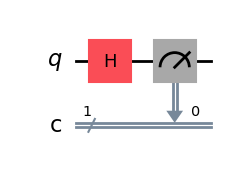

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import  AerSimulator
from qiskit_aer.noise import ReadoutError, NoiseModel
from qiskit import transpile
import matplotlib.pyplot as plt
import numpy as np

# 1 qubit 
qc1 = QuantumCircuit(1,1)
qc1.h(0)

# measurement
qc1.measure(0,0)

qc1.draw('mpl')

In [2]:
# simulation 
# p10 = P(measured=1 ∣ true=0)
p01, p10 = 0.1, 0.2
readout_error = ReadoutError([
    [1-p01 , p01  ],   # اندازه گیری 0  ---> سطر 0  p(j|0)   true state is 0
    [p10   , 1-p10]    # اندازه گیری 1 --> سطر 1    p(j|1)   true state is 1
])

noise_model = NoiseModel()
noise_model.add_readout_error(readout_error, [0])
sim = AerSimulator()

compiled = transpile(qc1, sim)

result = sim.run(compiled,noise_model= noise_model, shots=1024).result()

counts = result.get_counts()

print(counts)

print(readout_error)

# plt.hist(counts)

{'1': 467, '0': 557}
ReadoutError on 1 qubits. Assignment probabilities:
 P(j|0) =  [0.9 0.1]
 P(j|1) =  [0.2 0.8]


### Code in Python

In [5]:
## Matrix

p_true = np.array([0.5, 0.5])

M = np.array([
    [0.9, 0.2],  # a bit diff with qiskit
    [0.1, 0.8]
])

p_measure = M @ p_true

print('true value', p_true)
print('measure value', p_measure)

true value [0.5 0.5]
measure value [0.55 0.45]


## 2 Qubits

In [13]:
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError

import matplotlib.pyplot as plt
import numpy as np

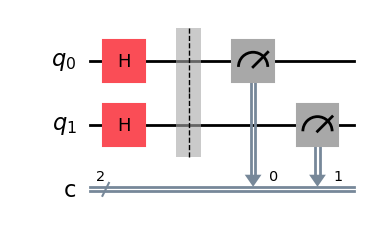

In [6]:
qc2 = QuantumCircuit(2,2)
qc2.h([0,1])
qc2.barrier()

qc2.measure([0,1],[0,1])

qc2.draw('mpl')

In [7]:
# For two independent qubits
# readout error برای کیوبیت اول و دوم
ro_error_1 = ReadoutError([[0.9, 0.1],
                           [0.2, 0.8]])
ro_error_2 = ReadoutError([[0.85, 0.15],
                           [0.15, 0.85]])

noise_model_2in = NoiseModel()
noise_model_2in.add_readout_error(ro_error_1,[0])
noise_model_2in.add_readout_error(ro_error_1,[1])

In [60]:
# for correlated qubits

ro_error_2q = ReadoutError([
    [0.8, 0.05, 0.05, 0.1],   # measured 00  sum of row must be 1
    [0.05,0.85,0.05,0.05],    # measured 01
    [0.05,0.05,0.85,0.05],    # measured 10
    [0.1,0.05,0.05,0.8]       # measured 11
])
noise_model2 = NoiseModel()
noise_model2.add_readout_error(ro_error_2q, [0,1])

sim2 = AerSimulator()
qc_compile = transpile(qc2, sim2)

result = sim2.run(qc_compile, noise_model=noise_model2, shots= 1024).result()

result.get_counts()
print(ro_error_2q)

ReadoutError on 2 qubits. Assignment probabilities:
 P(j|0) =  [0.8  0.05 0.05 0.1 ]
 P(j|1) =  [0.05 0.85 0.05 0.05]
 P(j|2) =  [0.05 0.05 0.85 0.05]
 P(j|3) =  [0.1  0.05 0.05 0.8 ]


In [8]:
## code in Python

# p_noisy = M @ P_true

p_true_2q = np.array([0.5,0,0,0.5])
M1 = np.array([
    [0.9, 0.1],
    [0.1, 0.9]
])

M2 = M1 = np.array([
    [0.85, 0.15],
    [0.15, 0.85]
])

M_2q = np.kron(M1, M2)

p_measure_2q = M_2q @ p_true_2q
# print(M_2q.shape)
# print(M_2q)
print(p_measure_2q)

[0.3725 0.1275 0.1275 0.3725]
